# Futures/Spot HBT Step-by-Step Runner

The notebook is intentionally thin. Configuration, pipeline stages, report tables, and plotting live in separate Python scripts in this folder. Both this notebook and `run_full_backtest.py` save CSV reports and PNG figures.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots

## 1. Parameters

In [ ]:
args = default_notebook_args(
    start_date='2026-03-01',
    end_date='2026-03-31',
    order_latency_ms=10.0,
    response_latency_ms=10.0,
    feed_latency_offset_ms=10.0,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=True,
)
args.output_dir

PosixPath('/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms')

## 2. Full Backtest and Core CSV Outputs

In [3]:
artifacts = run_backtest_pipeline(args)
display(artifacts.frame('summary').head(20))
display(artifacts.frame('entry_exit_index').head(20))

input_rows=164035
converted_rows=163620
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=415
raw_events=1980978
output_events=1980978
depth_events=1961280
trade_events=19698
opening_jump_qty=0.0
first_exch_ts=1775005201251796000
last_exch_ts=1775021099996999000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
output=/home/zoufuc/hftbacktest/data/tw_stock_events/1303_20260401_090000_132500.npz
input_rows=126805
converted_rows=126805
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=1525605
output_events=1525605
depth_events=1521660
trade_events=3945
opening_jump_qty=0.0
first_exch_ts=1775005200187000000
last_exch_ts=1775021097758000000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
output=/home/zoufuc/hftbacktest/data/tw_stock_future_events/CAFD6_20260401_090000_132500.npz
input_rows=25646
conver

,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,spot_tick_size,future_tick_size,first_leg,step_ns,second_leg_delay_ns,post_first_feed_wait,post_first_feed_timeout_ns,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns
0,2026-04-01,2026-04-01::1303_CAFD6,1303_CAFD6,1303,CAFD6,0,0,0,0,0.0,...,0.10,0.10,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
1,2026-04-01,2026-04-01::2002_CBFD6,2002_CBFD6,2002,CBFD6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
2,2026-04-01,2026-04-01::1301_CFFD6,1301_CFFD6,1301,CFFD6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
3,2026-04-01,2026-04-01::2324_CGFD6,2324_CGFD6,2324,CGFD6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
4,2026-04-01,2026-04-01::2409_CHFD6,2409_CHFD6,2409,CHFD6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
5,2026-04-01,2026-04-01::1605_CSFD6,1605_CSFD6,1605,CSFD6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
6,2026-04-01,2026-04-01::2408_CYFD6,2408_CYFD6,2408,CYFD6,0,0,0,0,0.0,...,0.50,0.50,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
7,2026-04-01,2026-04-01::1101_DFFD6,1101_DFFD6,1101,DFFD6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
8,2026-04-01,2026-04-01::1326_DGFD6,1326_DGFD6,1326,DGFD6,0,0,0,0,0.0,...,0.05,0.05,future,1000000000,0,spot,5000000000,10000000,10000000,10000000
9,2026-04-01,2026-04-01::2317_DHFD6,2317_DHFD6,2317,DHFD6,0,0,0,0,0.0,...,0.50,0.50,future,1000000000,0,spot,5000000000,10000000,10000000,10000000


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-04-01,2026-04-01::1303_CAFD6,1303_CAFD6,0,0,0,0
1,2026-04-01,2026-04-01::2002_CBFD6,2002_CBFD6,0,0,0,0
2,2026-04-01,2026-04-01::1301_CFFD6,1301_CFFD6,0,0,0,0
3,2026-04-01,2026-04-01::2324_CGFD6,2324_CGFD6,0,0,0,0
4,2026-04-01,2026-04-01::2409_CHFD6,2409_CHFD6,0,0,0,0
5,2026-04-01,2026-04-01::1605_CSFD6,1605_CSFD6,0,0,0,0
6,2026-04-01,2026-04-01::2408_CYFD6,2408_CYFD6,0,0,0,0
7,2026-04-01,2026-04-01::1101_DFFD6,1101_DFFD6,0,0,0,0
8,2026-04-01,2026-04-01::1326_DGFD6,1326_DGFD6,0,0,0,0
9,2026-04-01,2026-04-01::2317_DHFD6,2317_DHFD6,0,0,0,0


## 3. Analysis CSV Outputs

In [4]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('roi_summary_including_open'))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,6213,15,2,150785.9900,10052.399333,68,0,0,10.0
1,3037,7,2,144533.4860,20647.640857,42,1,0,0.0
2,1303,19,2,11620.5420,611.607474,60,0,0,40.0
3,3673,3,2,6738.9396,2246.313200,8,0,0,0.0
4,6290,2,1,4163.3130,2081.656500,4,0,0,0.0
5,8358,8,2,3284.2230,410.527875,2,0,0,0.0
6,2324,16,2,2274.2516,142.140725,8,0,0,0.0
7,6147,8,2,1603.4770,200.434625,4,0,0,0.0
8,3481,20,2,1098.7980,54.939900,30,0,0,10.0
9,3714,7,2,580.1392,82.877029,2,1,0,0.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,26,11062,231542,5,26,11056.0


,entry_cash_out,net_stock_cash_stuck,realized_pnl,open_locked_pnl,total_pnl_including_open,total_roi_on_entry_cash_pct,open_roi_on_stuck_cash_pct,open_pairs
0,1.590240e+08,5.187427e+07,660883.9342,546187.0224,1.207071e+06,0.00759,0.010529,130.0


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms/reports


## 4. Saved PNG Outputs

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms/figures/performance_overview.png


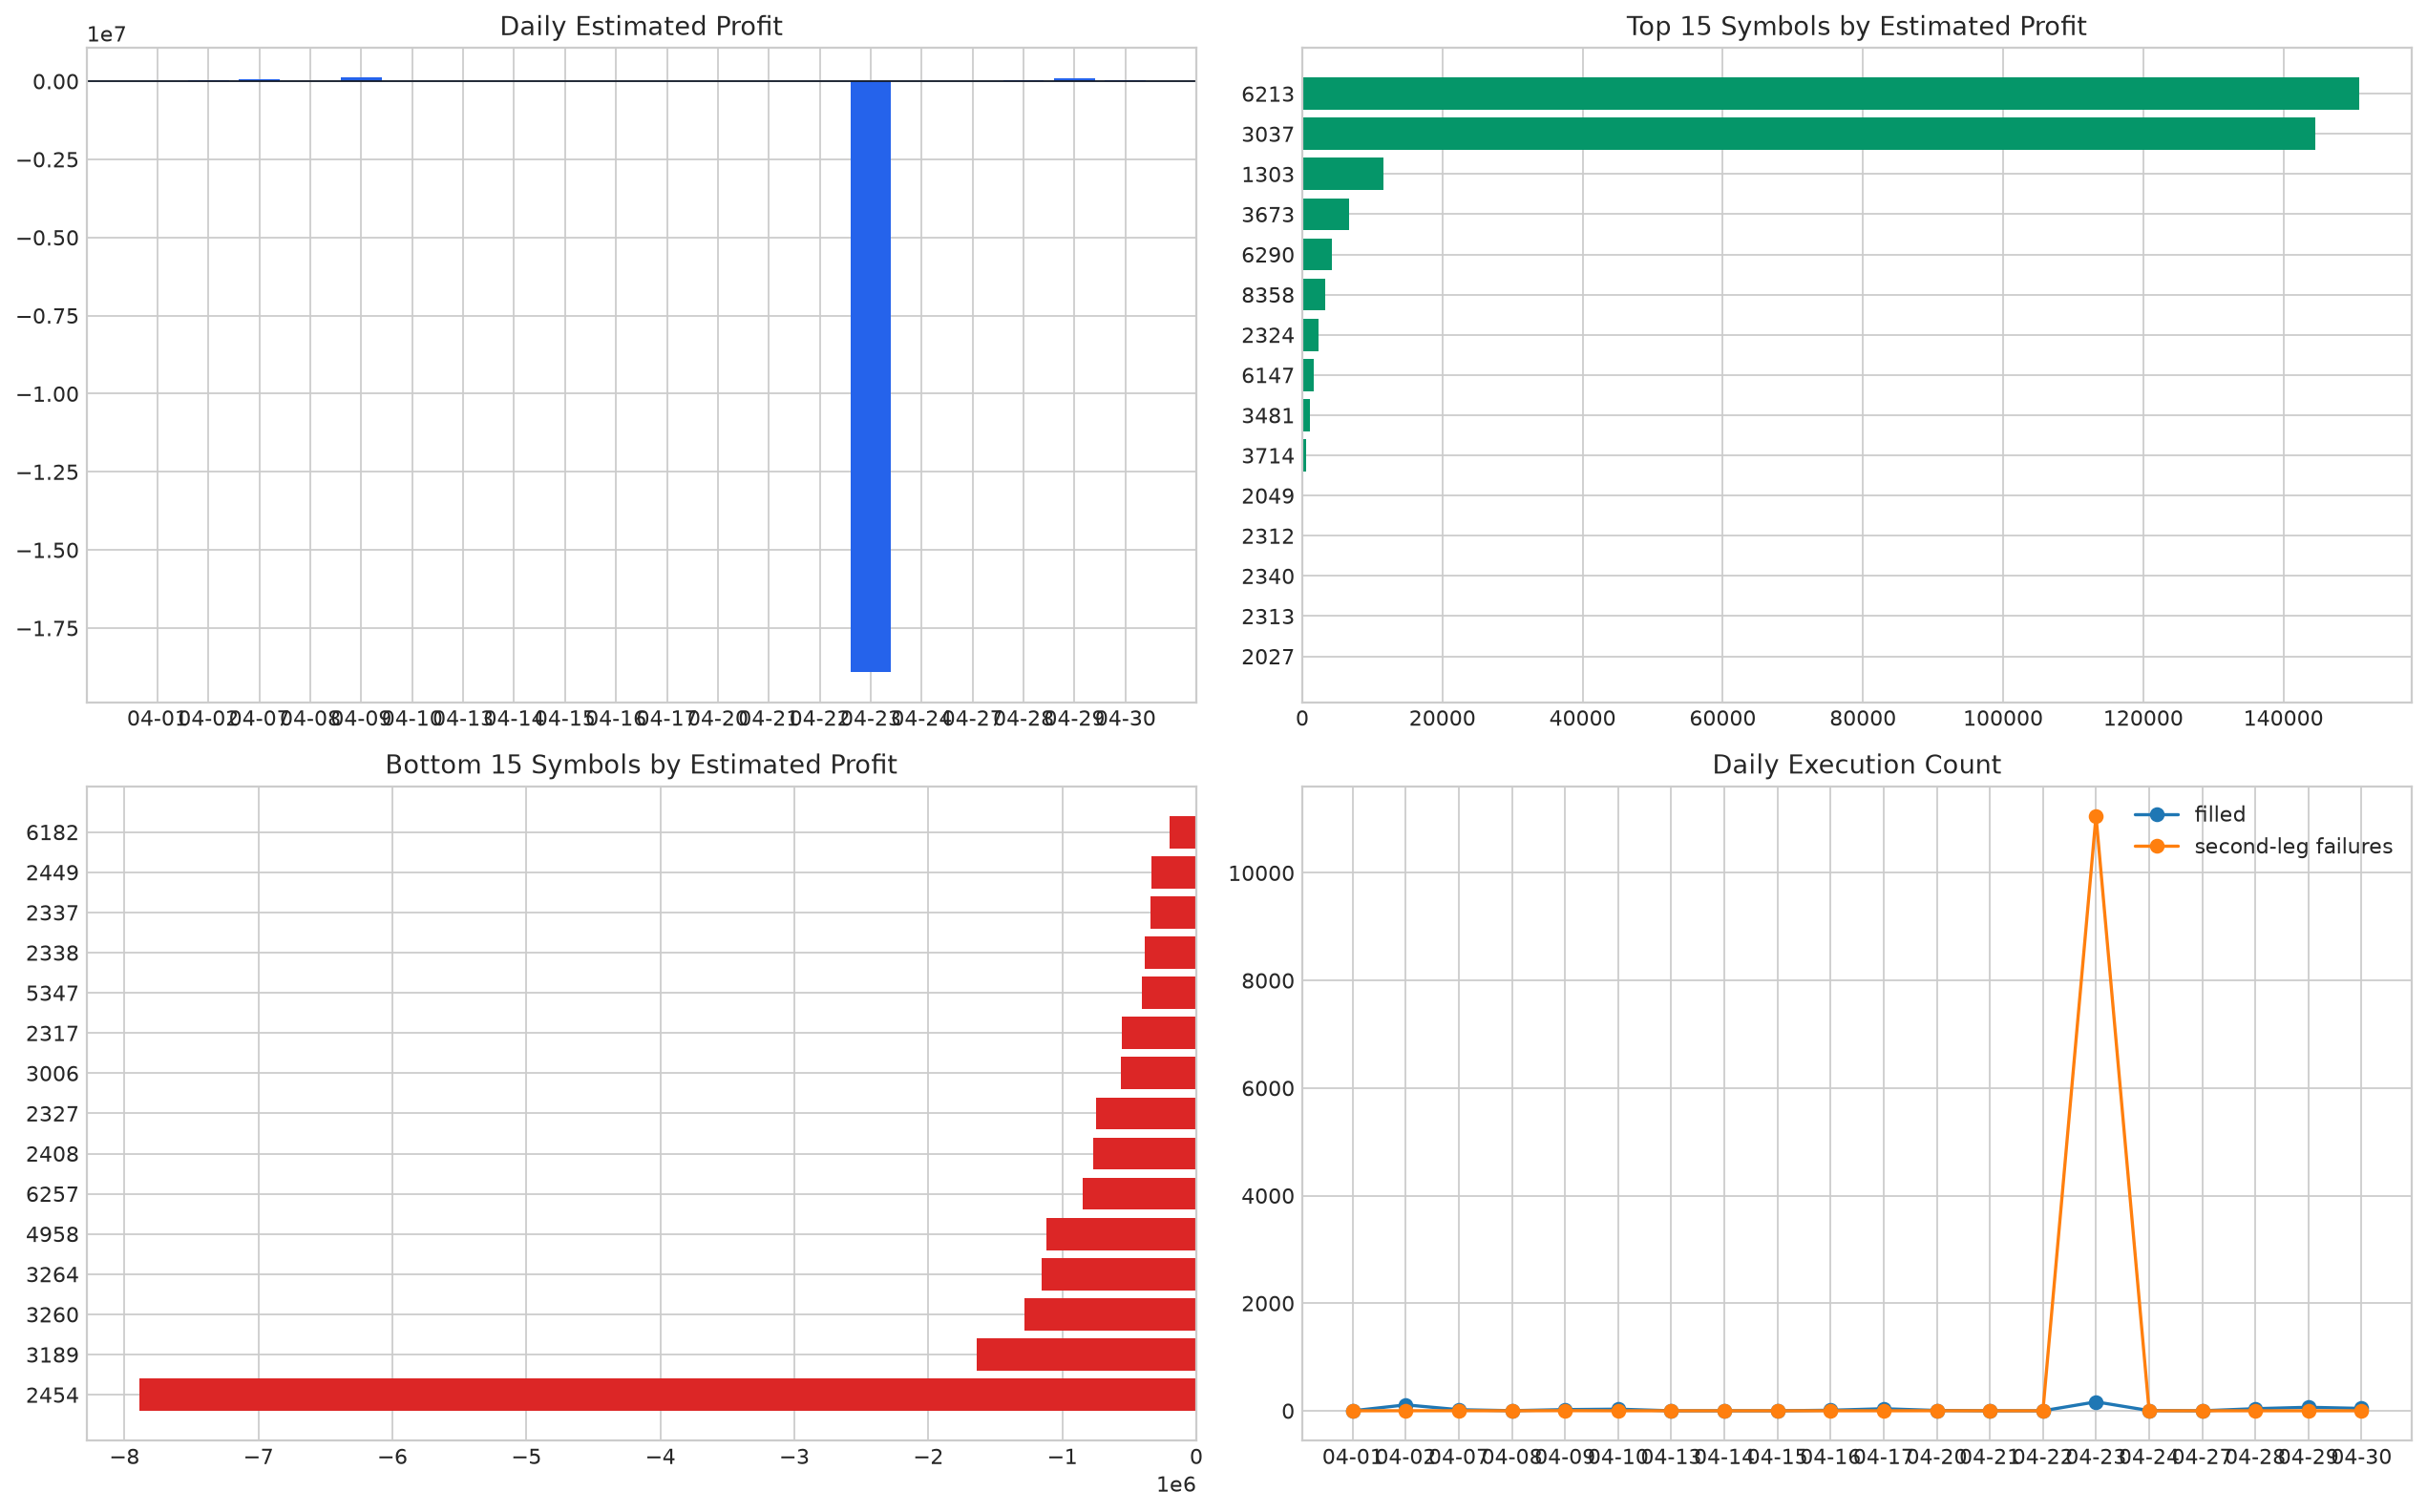

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms/figures/pair_profit_scatter.png


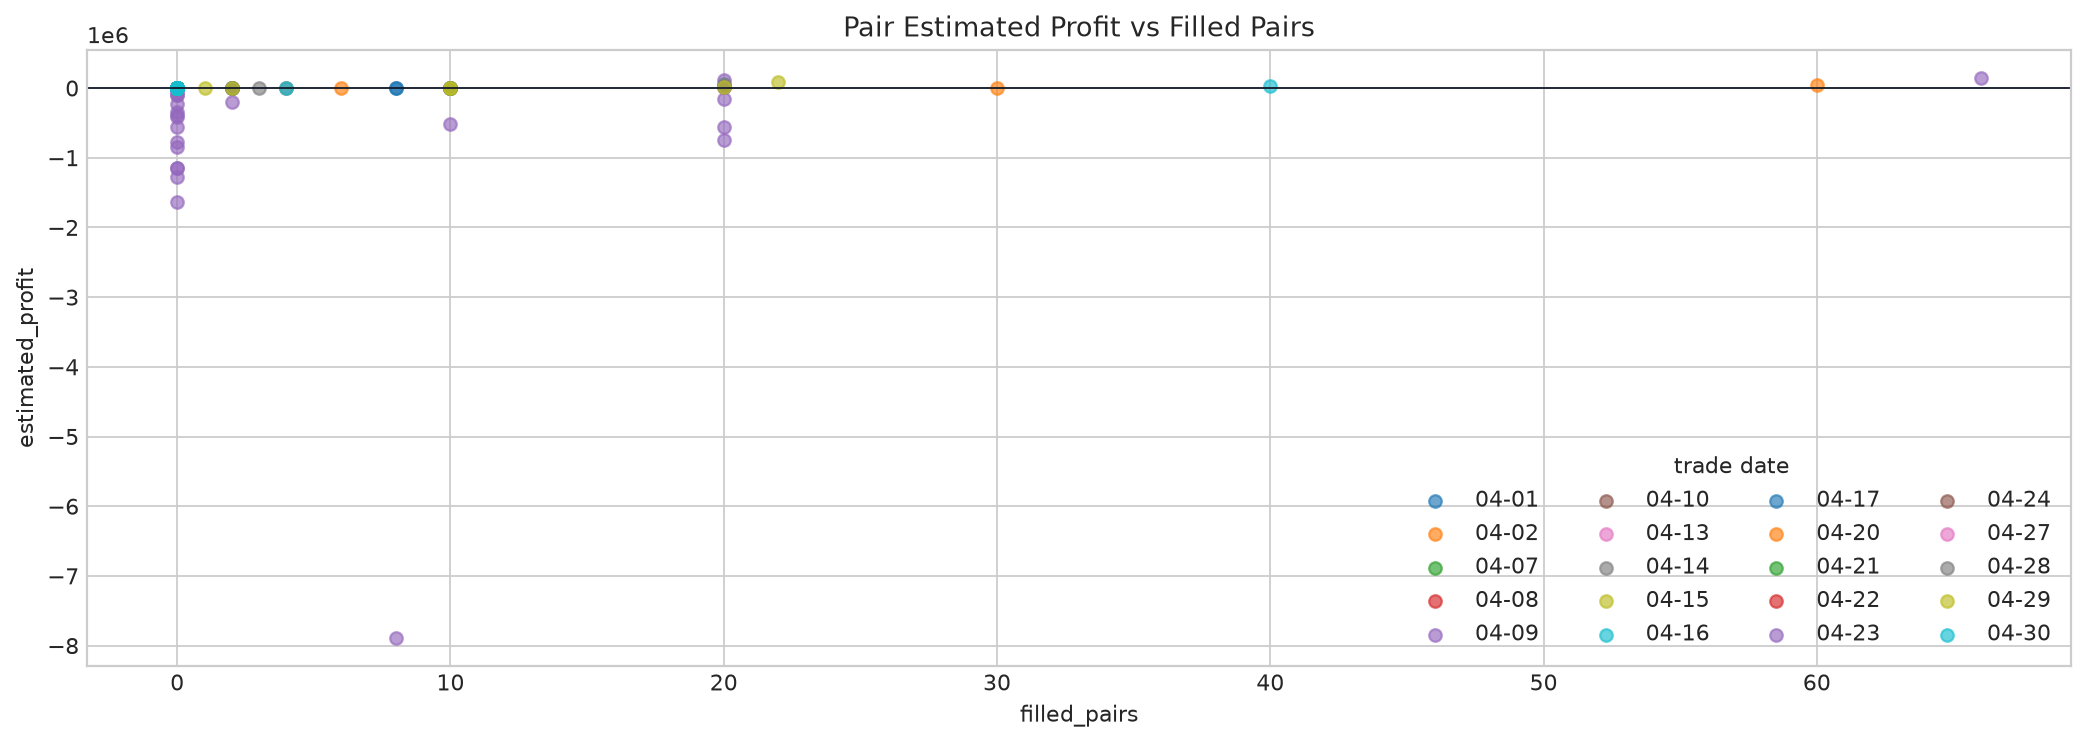

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms/figures/stuck_cash.png


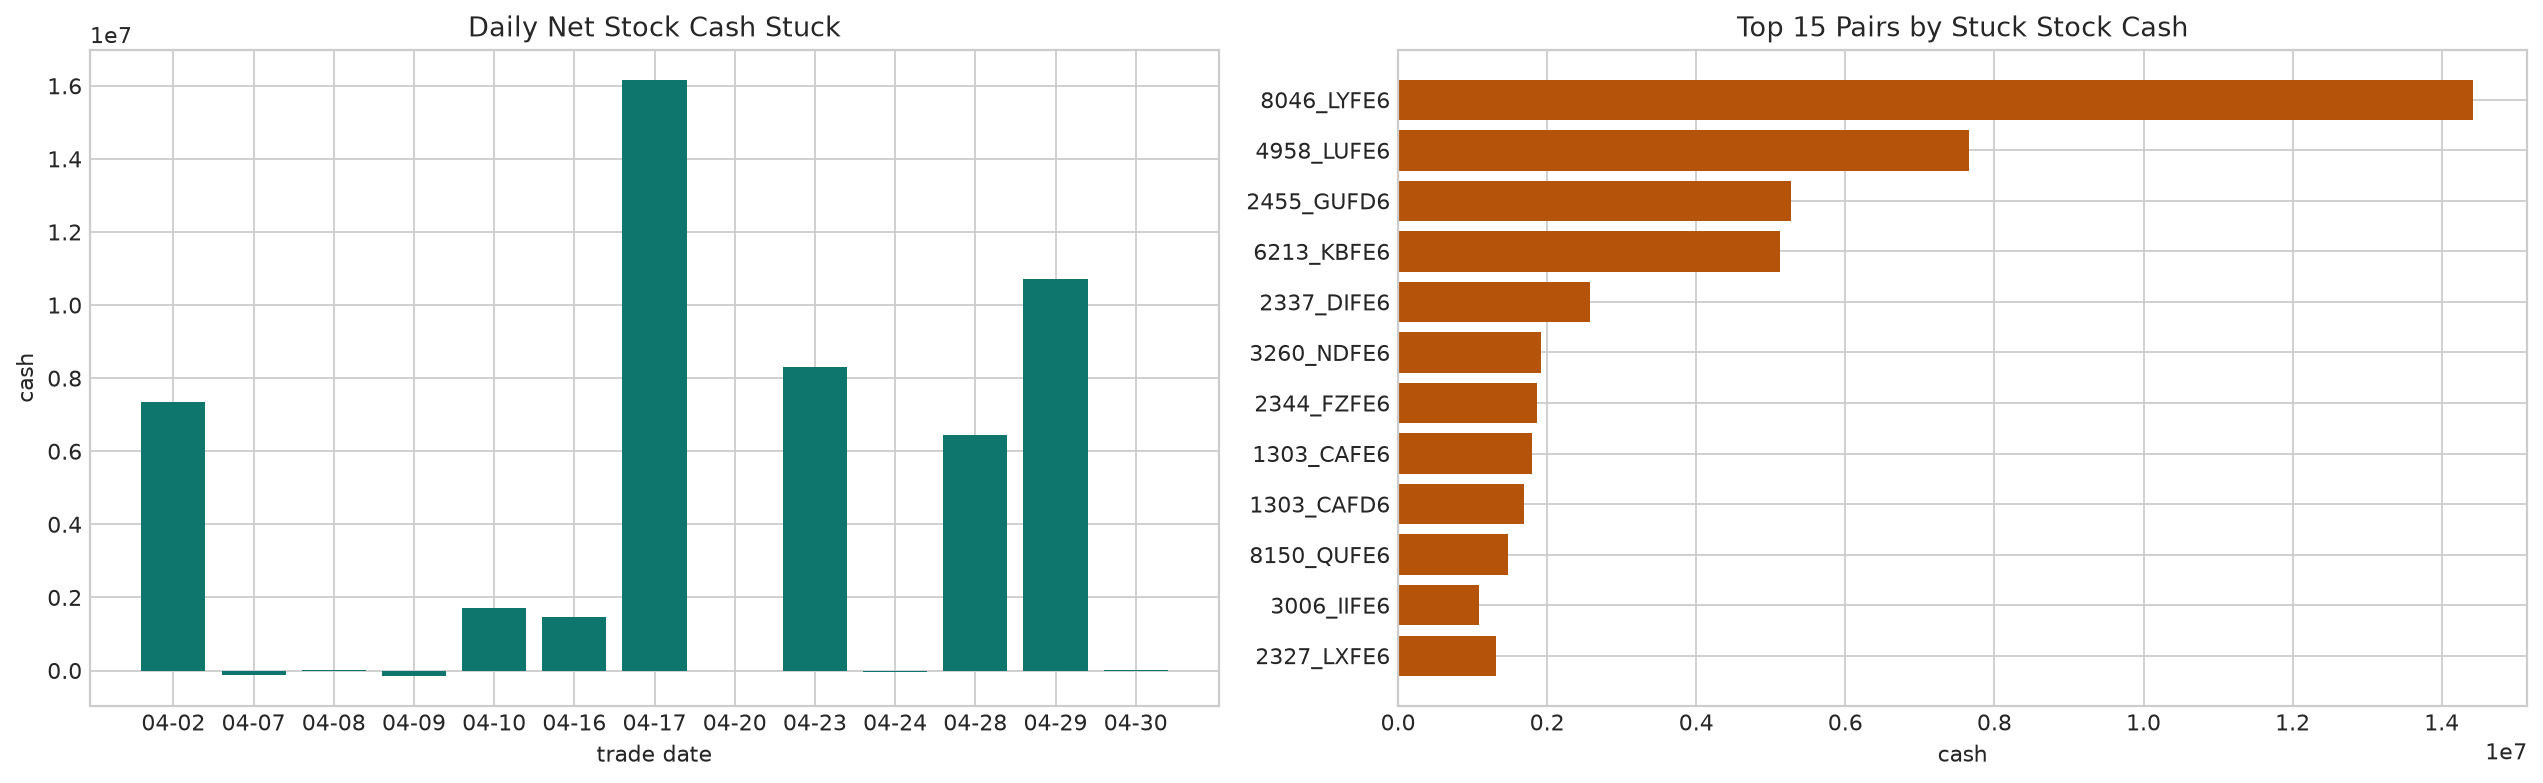

roi_including_open: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms/figures/roi_including_open.png


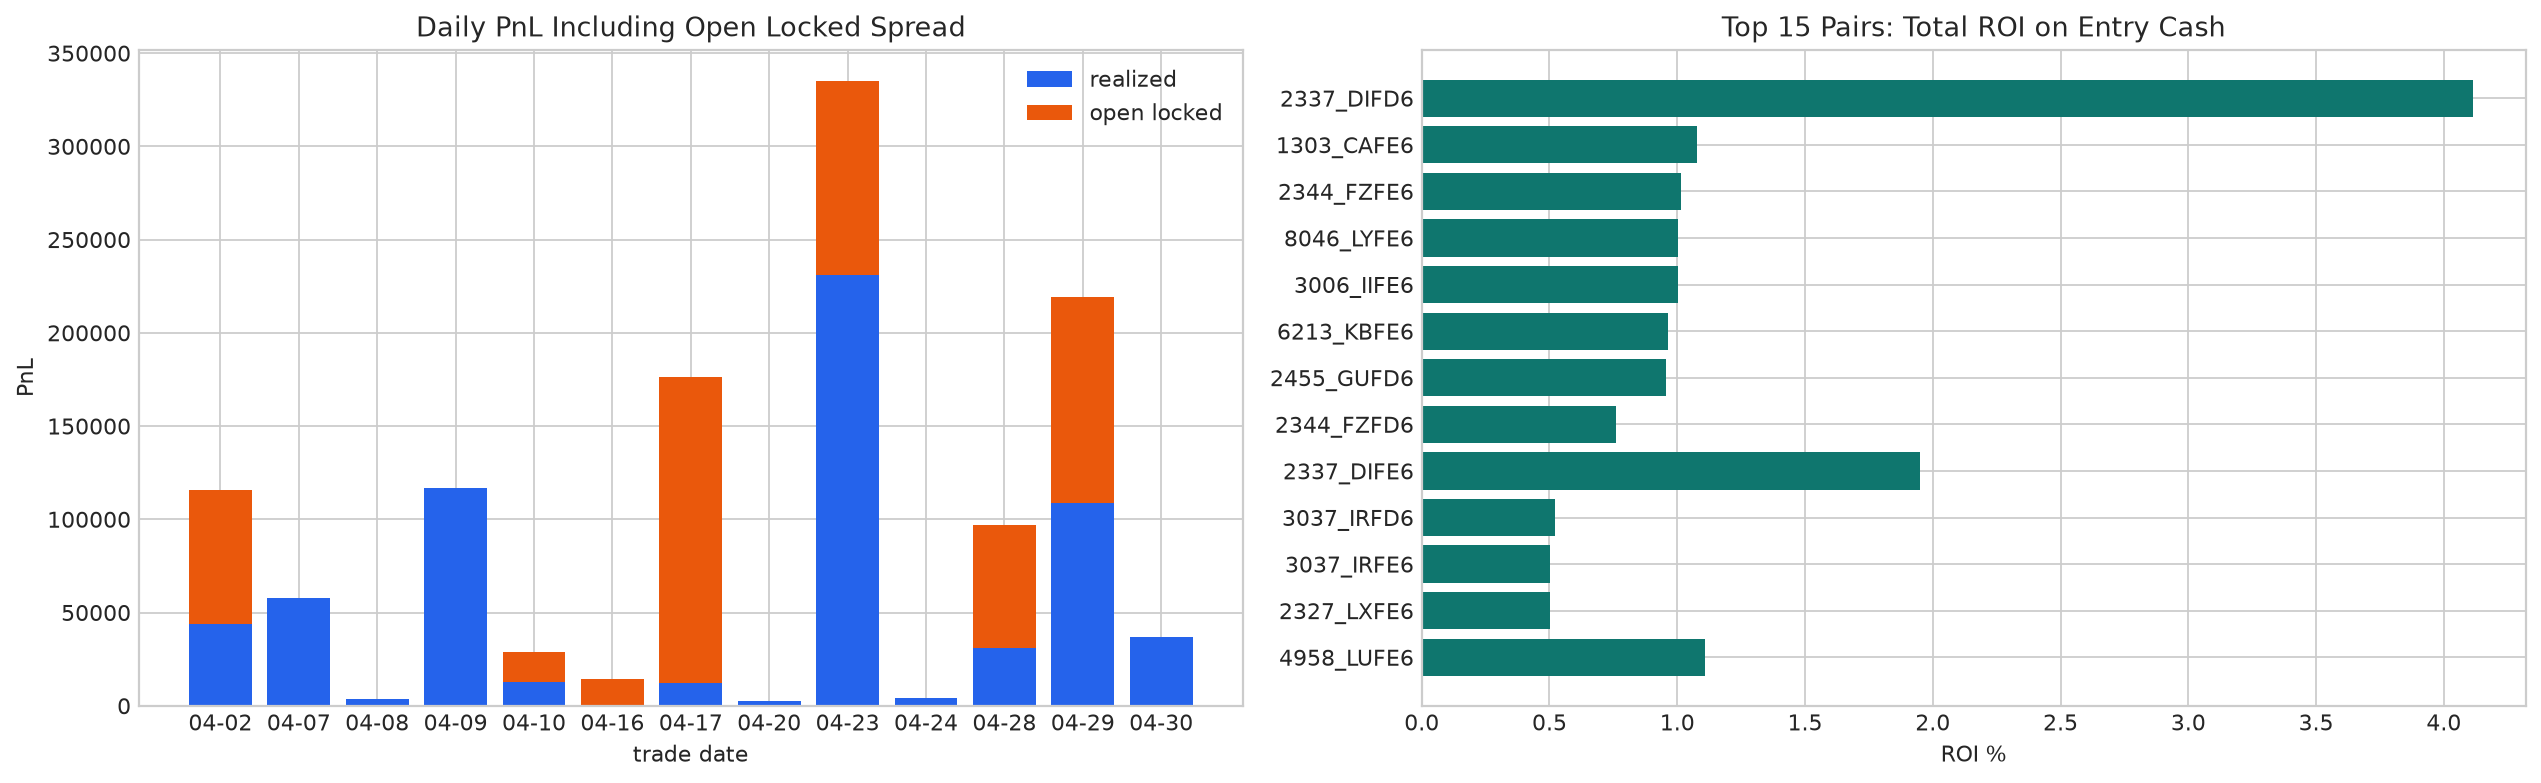

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms/figures/latency_timelines.png


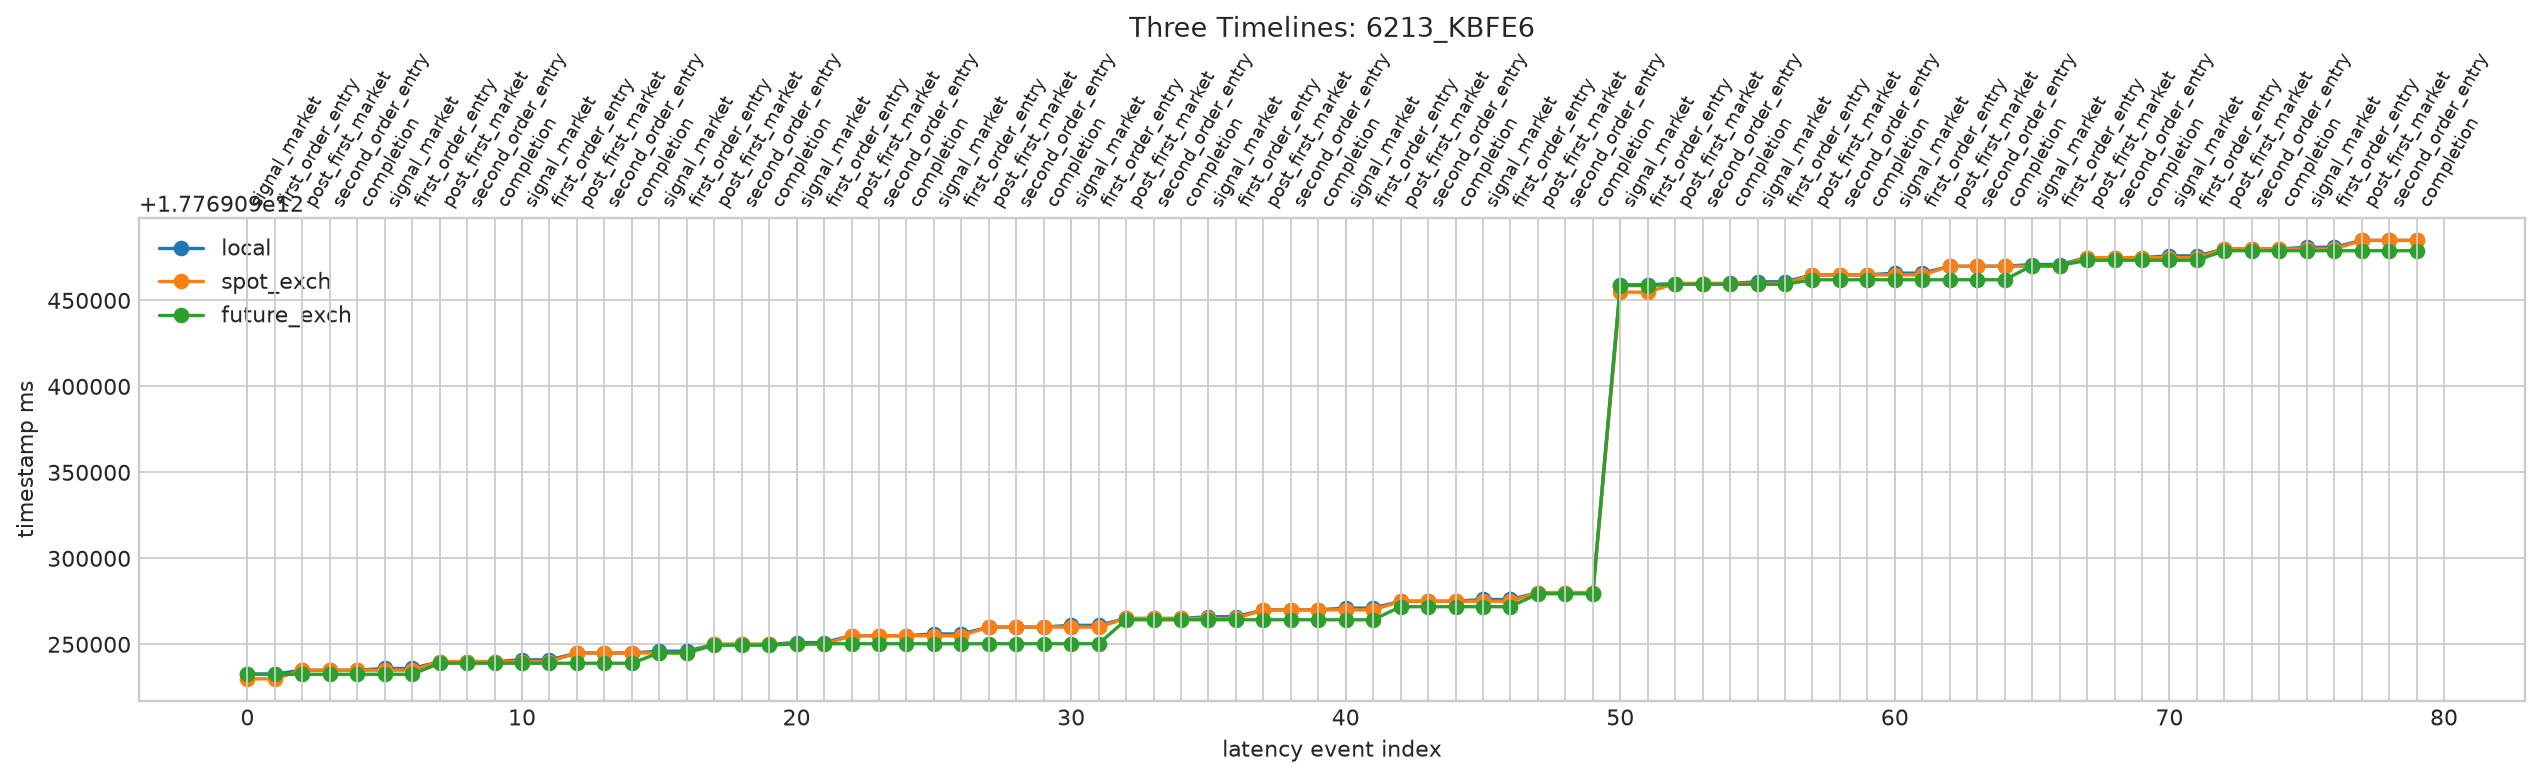

In [5]:
figure_paths = save_report_plots(artifacts, reports)
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## 5. Optional Drill-down

In [6]:
selected_pair = reports.selected_pair
entry_exit = artifacts.frame('entry_exit_all')
latency = artifacts.frame('latency')
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    if 'pair_name' in entry_exit.columns:
        display(entry_exit.loc[entry_exit['pair_name'].eq(selected_pair)].head(100))
    if 'pair_name' in latency.columns:
        display(latency.loc[latency['pair_name'].eq(selected_pair)].head(120))

,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
92836,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:53:52.722376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,279.5,280.0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92837,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:53:54.952376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,279.5,280.0,NaN,...,sell,284.0,284.0,1.0,stock,buy,281.0,280.0,2.0,2209.999872
92838,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:53:55.952376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,279.5,280.0,52.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92839,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:53:59.972376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,279.5,280.0,NaN,...,sell,284.0,284.0,1.0,stock,buy,281.0,280.0,2.0,4000.000000
92840,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:54:00.972376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,279.5,280.0,57.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92931,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:55:21.092376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,280.5,281.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92932,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:55:22.092376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,280.5,281.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92933,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:55:22.092376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,280.5,281.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92934,2026-04-23,2026-04-23::6213_KBFE6,2026-04-23 09:55:23.092376+08:00,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,280.5,281.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
26504,2026-04-23,2026-04-23::6213_KBFE6,1776909232722376000,3230,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1776909232554000000,1776909232564000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-04-23 09:53:52.722376+08:00
26505,2026-04-23,2026-04-23::6213_KBFE6,1776909232742376000,3230,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1776909232554000000,1776909232564000000,10000000,1.776909e+18,1.776909e+18,1.776909e+18,10000000.0,10000000.0,2026-04-23 09:53:52.722376+08:00
26506,2026-04-23,2026-04-23::6213_KBFE6,1776909234932376000,3230,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1776909232554000000,1776909232564000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-04-23 09:53:54.932376+08:00
26507,2026-04-23,2026-04-23::6213_KBFE6,1776909234952376000,3230,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1776909232554000000,1776909232564000000,10000000,1.776909e+18,1.776909e+18,1.776909e+18,10000000.0,10000000.0,2026-04-23 09:53:54.932376+08:00
26508,2026-04-23,2026-04-23::6213_KBFE6,1776909234952376000,3230,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,None,...,10000000,1776909232554000000,1776909232564000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-04-23 09:53:54.952376+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26619,2026-04-23,2026-04-23::6213_KBFE6,1776909521052376000,3431,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1776909519799000000,1776909519809000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-04-23 09:58:41.052376+08:00
26620,2026-04-23,2026-04-23::6213_KBFE6,1776909521072376000,3431,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1776909519799000000,1776909519809000000,10000000,1.776910e+18,1.776910e+18,1.776910e+18,10000000.0,10000000.0,2026-04-23 09:58:41.052376+08:00
26621,2026-04-23,2026-04-23::6213_KBFE6,1776909525042376000,3431,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1776909523916000000,1776909523926000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-04-23 09:58:45.042376+08:00
26622,2026-04-23,2026-04-23::6213_KBFE6,1776909525062376000,3431,6213_KBFE6,6213,KBFE6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1776909523916000000,1776909523926000000,10000000,1.776910e+18,1.776910e+18,1.776910e+18,10000000.0,10000000.0,2026-04-23 09:58:45.042376+08:00
